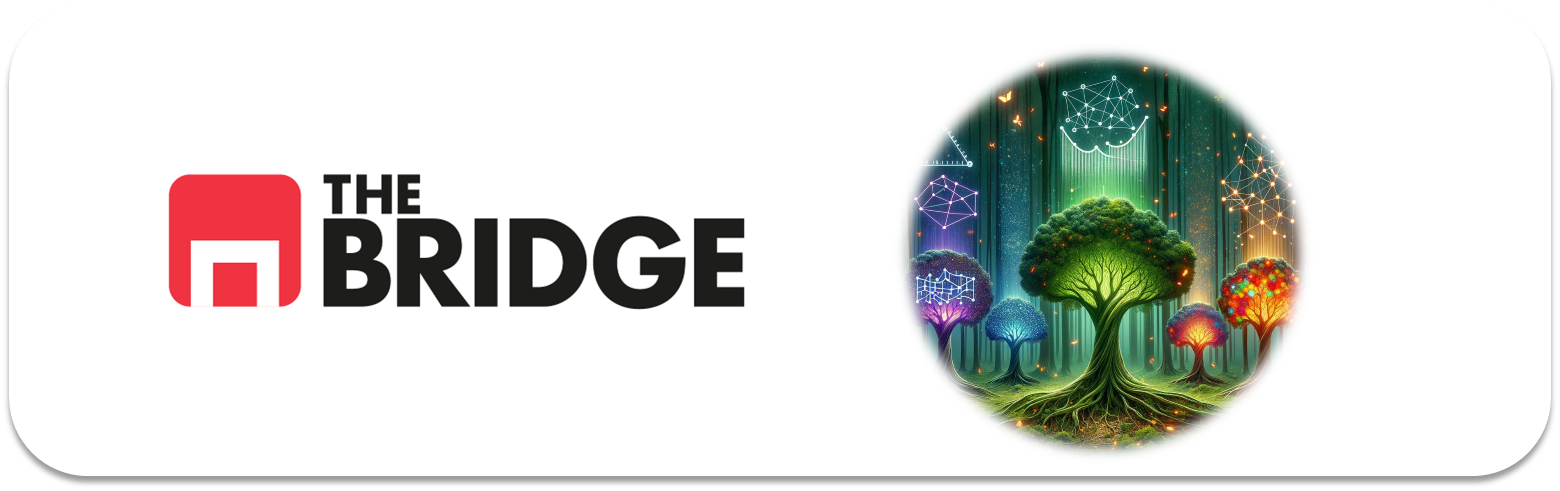

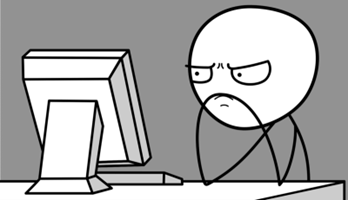

Para ejercitarte y afianzar lo aprendido sobre **Bagging y Boosting**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0.1

Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


### Ejercicio 0.2

Carga el dataset conocido como Mnist y vuélcalo en un array en numpy. Ejecuta la siguiente celda:

In [3]:
df = pd.read_csv('.\data\mnist_csv')
df.head(5)

X = df.drop(columns=['numero']).values
y = df['numero'].values



<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\blanc.TORRE-BLANCA\AppData\Local\Temp\ipykernel_17980\4153118725.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('.\data\mnist_csv')


### Ejercicio 1

Muestra el contenido del dataset, las primersas 5 filas. Y luego utiliza la función que tienes a continuaicón para mostrar cada instancia de una forma gráfica. Muestra las cinco primeras y el target de las mismas

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mnist_images(images, bck_white = False):
    """
    Función para mostrar imágenes del dataset MNIST.

    :param images: Array de numpy con múltiples imágenes, cada una de 784 elementos.
    """
    # Número de imágenes
    num_images = len(images)

    # Crear una cuadrícula de subplots
    cols = int(np.sqrt(num_images))
    rows = (num_images // cols) + 1

    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < num_images:
            # Convertir cada imagen de 784 elementos a un array 2D de 28x28
            img_matrix = images[i].reshape(28, 28)

            # Mostrar la imagen
            ax.imshow(img_matrix, cmap='gray' if not bck_white else "binary" )

            # Quitar los ejes
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()



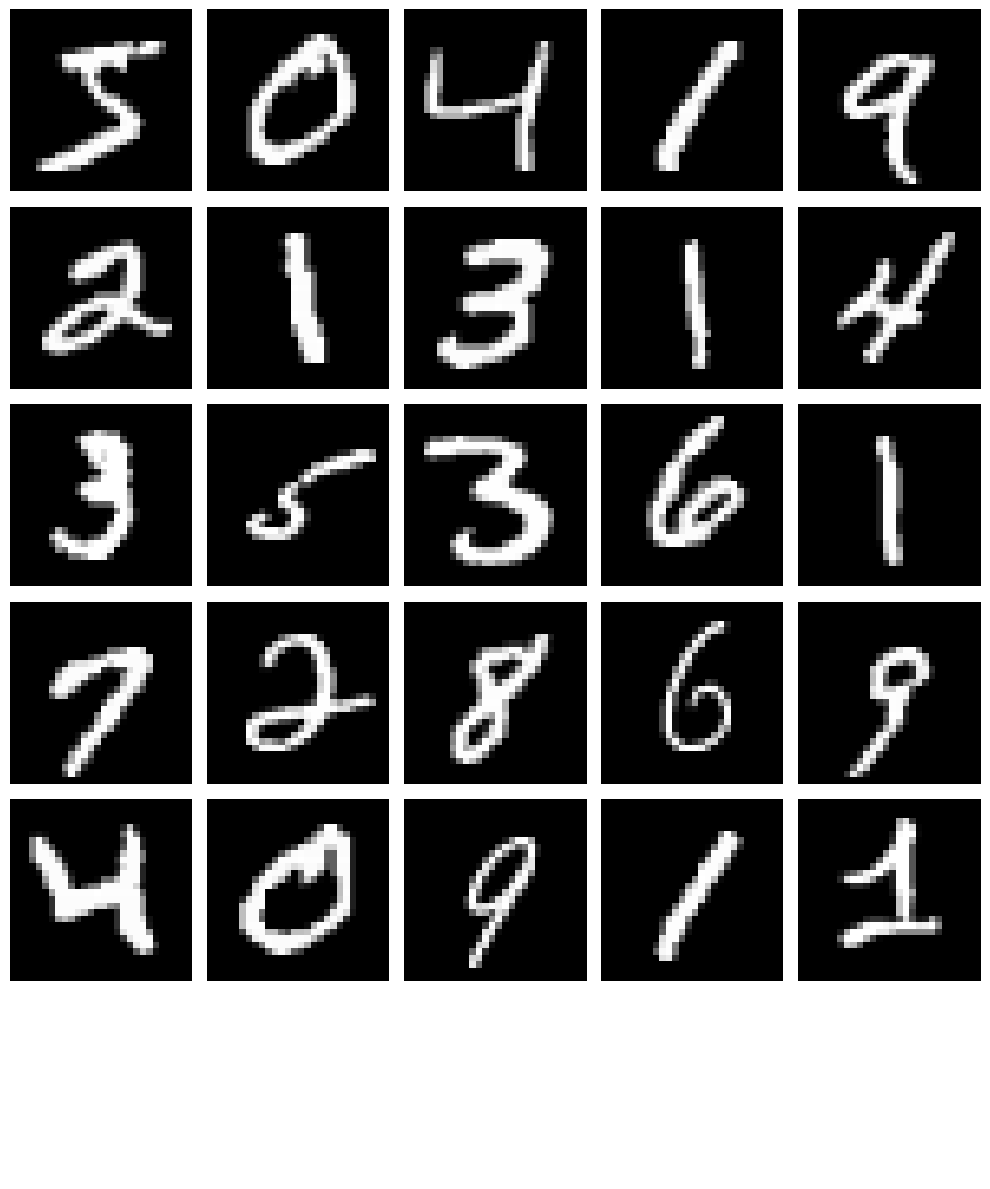

In [5]:
plot_mnist_images(X[:25])

¿Cuántos pixeles tiene de alto y ancho cada imagen?

In [6]:
img = X[0].reshape(28, 28)
img.shape


(28, 28)

### Ejercicio 2

Separa en train y test. Muestra el número de instancias para cada grupo

In [7]:
from sklearn.model_selection import train_test_split

# Separar en train y test (80% train, 20% test por defecto)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Mostrar número de instancias
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

print("Distribución en train:", np.bincount(y_train))
print("Distribución en test:", np.bincount(y_test))



Tamaño de X_train: (800, 784)
Tamaño de X_test: (200, 784)
Tamaño de y_train: (800,)
Tamaño de y_test: (200,)
Distribución en train: [78 93 79 74 84 74 75 94 69 80]
Distribución en test: [19 23 20 19 21 18 19 23 18 20]


### Ejercicio 3

Entrena un clasificador basado en Random Forest. Haz la predicción sobre los 5 primeros elementos del dataset de train y comprueba visualmente cuánto ha acertado.

In [8]:
X_sample = X_train[:5]
y_true = y_train[:5]


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Crear y entrenar el modelo 

rf = RandomForestClassifier(
    n_estimators= 200,
    random_state= 42,
    n_jobs=1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
y_pred = rf.predict(X_sample)

print("Etiquetas reales:", y_true)
print("Predicciones    :", y_pred)


Etiquetas reales: [6 2 3 9 2]
Predicciones    : [6 2 3 9 2]


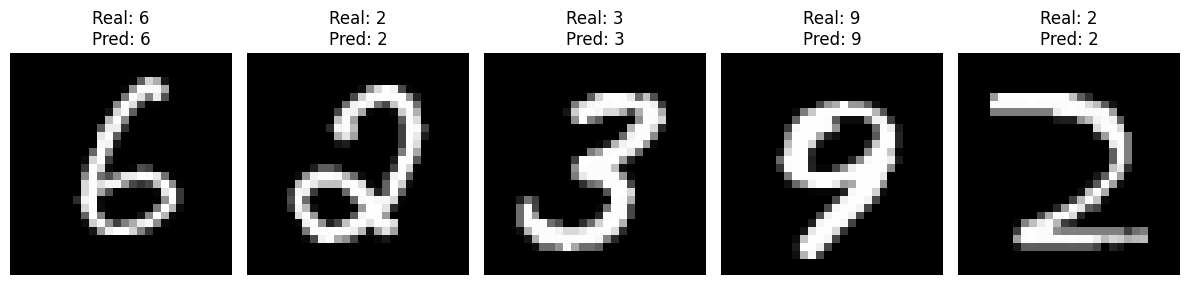

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i, ax in enumerate(axes):
    img = X_sample[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {y_true[i]}\nPred: {y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


### Ejercicio 4

Pruébalo contra test y muestra su informe de clasificación

In [12]:
y_pred_test = rf.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87        19
           1       0.96      1.00      0.98        23
           2       0.90      0.90      0.90        20
           3       0.82      0.74      0.78        19
           4       0.95      1.00      0.98        21
           5       0.93      0.78      0.85        18
           6       0.86      0.95      0.90        19
           7       0.83      0.87      0.85        23
           8       0.94      0.89      0.91        18
           9       0.85      0.85      0.85        20

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



Matriz de confusión

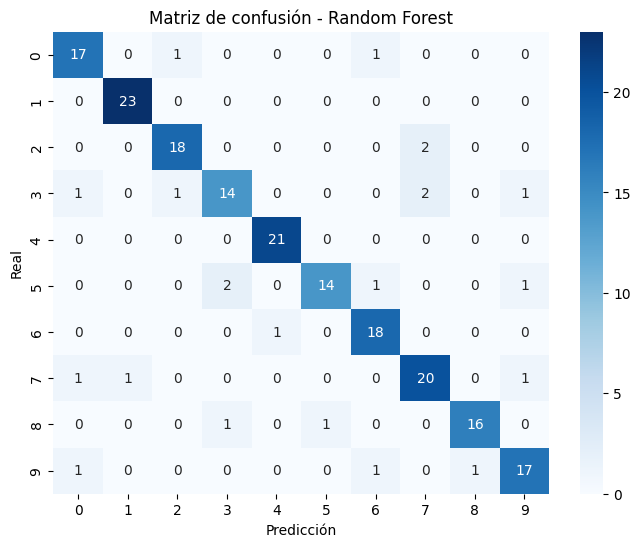

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest")
plt.show()


### Ejercicio 5

Obten la feature importance del modelo pero muéstrala como una imagen para que veamos que píxeles son más importantes (hay tantos coeficientes como píxeles, recuerda). PISTA: Igual puedes usar parte del código de la función anterior o todo.

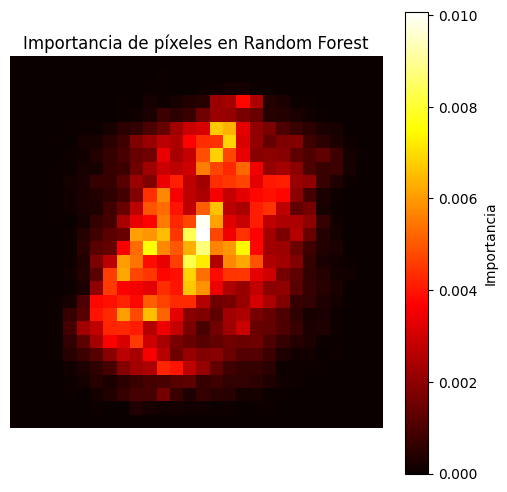

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Obtener importancias del modelo
importances = rf.feature_importances_

# Convertir a matriz 28x28
importances_img = importances.reshape(28, 28)

# Mostrar como imagen
plt.figure(figsize=(6, 6))
plt.imshow(importances_img, cmap='hot')
plt.title("Importancia de píxeles en Random Forest")
plt.colorbar(label="Importancia")
plt.axis('off')
plt.show()


### Ejercicio 6 

Entrena ahora un ensamblado basado en el Gradient Boosted Trees de sklearn. Muestra la predicción de los números en las posiciones 20 a 25 de train y su target.

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gbt = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbt.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [16]:
X_sample = X_train[20:26]
y_true = y_train[20:26]


In [17]:
y_pred = gbt.predict(X_sample)

print("Etiquetas reales:", y_true)
print("Predicciones    :", y_pred)


Etiquetas reales: [5 7 2 8 3 2]
Predicciones    : [5 7 2 8 3 2]


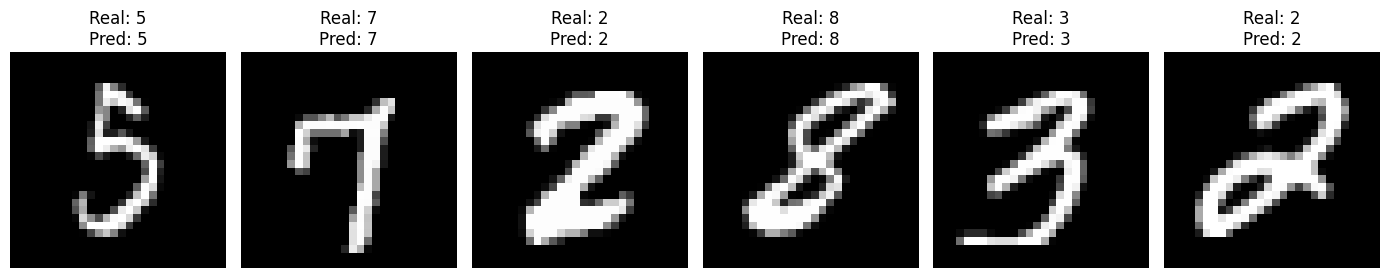

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(14, 3))

for i, ax in enumerate(axes):
    img = X_sample[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {y_true[i]}\nPred: {y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


### Ejercicio 7

Pruébalo contra test y muestra su informe de clasificación

In [19]:
y_pred_test_gbt = gbt.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test_gbt))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76        19
           1       0.92      0.96      0.94        23
           2       0.90      0.90      0.90        20
           3       0.87      0.68      0.76        19
           4       0.95      0.86      0.90        21
           5       0.87      0.72      0.79        18
           6       0.86      0.95      0.90        19
           7       0.95      0.83      0.88        23
           8       0.81      0.94      0.87        18
           9       0.67      0.90      0.77        20

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200



### Ejercicio 8

Entrena ahora un ensamblado basado en XGBoost. Muestra la predicción de los números en las posiciones 50 a 55 de train y su target.

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=10,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [21]:
X_sample = X_train[50:56]
y_true = y_train[50:56]


In [22]:
y_pred = xgb.predict(X_sample)

print("Etiquetas reales:", y_true)
print("Predicciones    :", y_pred)


Etiquetas reales: [8 6 7 7 1 5]
Predicciones    : [8 6 7 7 1 5]


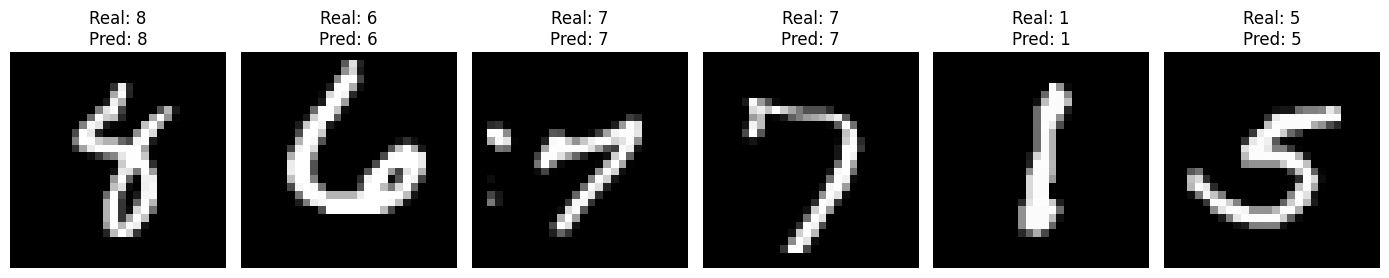

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(14, 3))

for i, ax in enumerate(axes):
    img = X_sample[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {y_true[i]}\nPred: {y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


### Ejercicio 9

Pruébalo contra test y muestra su informe de clasificación

In [24]:
y_pred_test_xgb = xgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test_xgb))


              precision    recall  f1-score   support

           0       0.80      0.84      0.82        19
           1       0.88      0.96      0.92        23
           2       0.81      0.85      0.83        20
           3       0.88      0.74      0.80        19
           4       0.91      0.95      0.93        21
           5       0.82      0.78      0.80        18
           6       0.94      0.89      0.92        19
           7       0.87      0.87      0.87        23
           8       0.95      1.00      0.97        18
           9       0.89      0.85      0.87        20

    accuracy                           0.88       200
   macro avg       0.88      0.87      0.87       200
weighted avg       0.88      0.88      0.87       200



### Ejercicio 10

Entrena ahora un ensamblado basado en LightGBM. Muestra la predicción de los números en las posiciones 125 a 130 de train y su target.

In [25]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multiclass',
    num_class=10,
    random_state=42
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23378
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 450
[LightGBM] [Info] Start training from score -2.327903
[LightGBM] [Info] Start training from score -2.152012
[LightGBM] [Info] Start training from score -2.315164
[LightGBM] [Info] Start training from score -2.380547
[LightGBM] [Info] Start training from score -2.253795
[LightGBM] [Info] Start training from score -2.380547
[LightGBM] [Info] Start training from score -2.367124
[LightGBM] [Info] Start training from score -2.141317
[LightGBM] [Info] Start training from score -2.450505
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [26]:
X_sample = X_train[125:131]
y_true = y_train[125:131]

In [27]:
y_pred = lgbm.predict(X_sample)

print("Etiquetas reales:", y_true)
print("Predicciones    :", y_pred)

Etiquetas reales: [9 5 2 4 0 8]
Predicciones    : [9 5 2 4 0 8]


c:\Users\blanc.TORRE-BLANCA\OneDrive\Escriptori\bootcamp-data\DS-Online-blanca\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


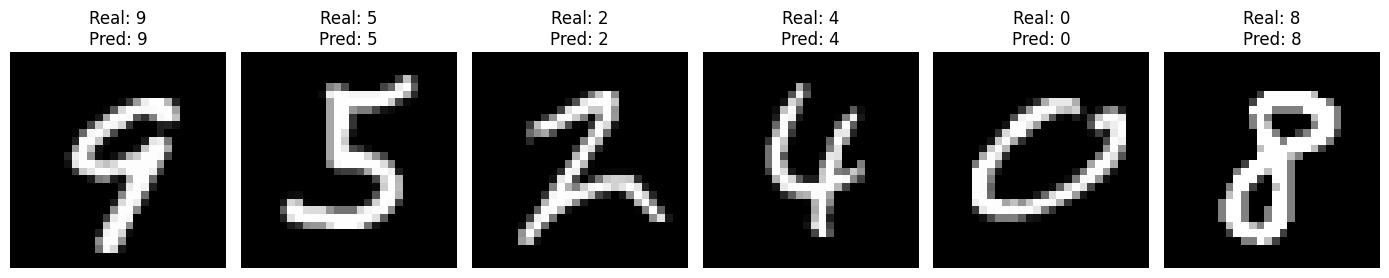

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(14, 3))

for i, ax in enumerate(axes):
    img = X_sample[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {y_true[i]}\nPred: {y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

### Ejercicio 11

Pruébalo contra test y muestra su informe de clasificación

In [29]:
y_pred_test_lgbm = lgbm.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test_lgbm))


              precision    recall  f1-score   support

           0       0.84      0.84      0.84        19
           1       0.96      0.96      0.96        23
           2       0.90      0.90      0.90        20
           3       0.89      0.84      0.86        19
           4       0.95      0.95      0.95        21
           5       0.93      0.78      0.85        18
           6       0.81      0.89      0.85        19
           7       0.80      0.87      0.83        23
           8       0.90      1.00      0.95        18
           9       0.94      0.85      0.89        20

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



c:\Users\blanc.TORRE-BLANCA\OneDrive\Escriptori\bootcamp-data\DS-Online-blanca\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Ejercicio 12

Entrena ahora un ensamblado basado en CatBoost. Muestra la predicción de los números en las posiciones 305 a 310 de train y su target.

In [30]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    loss_function='MultiClass',
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train)


In [31]:
X_sample = X_train[305:311]
y_true = y_train[305:311]


In [32]:
y_pred = cat.predict(X_sample).astype(int).flatten()

print("Etiquetas reales:", y_true)
print("Predicciones    :", y_pred)


Etiquetas reales: [7 5 0 4 3 0]
Predicciones    : [7 5 0 4 3 0]


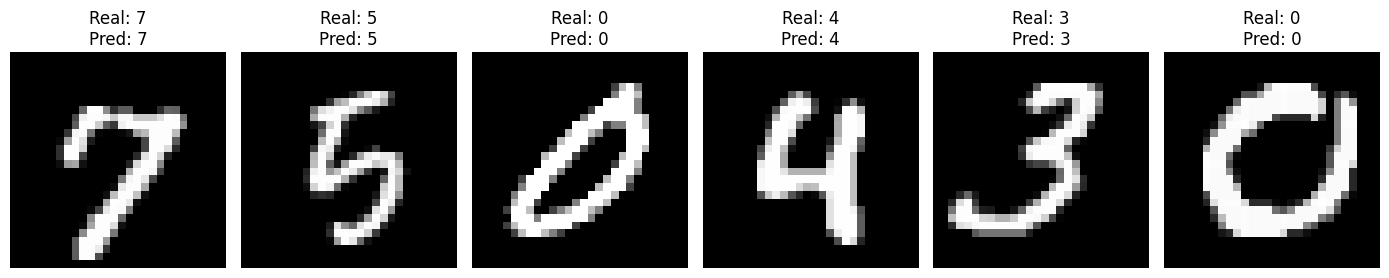

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(14, 3))

for i, ax in enumerate(axes):
    img = X_sample[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {y_true[i]}\nPred: {y_pred[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


### Ejercicio 13

Pruébalo contra test y muestra su informe de clasificación

In [35]:
y_pred_test_cat = cat.predict(X_test).astype(int).flatten()

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_test_cat))


              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      1.00      1.00        23
           2       0.95      0.95      0.95        20
           3       0.83      0.79      0.81        19
           4       0.95      0.90      0.93        21
           5       1.00      0.78      0.88        18
           6       0.81      0.89      0.85        19
           7       0.88      0.91      0.89        23
           8       1.00      0.94      0.97        18
           9       0.82      0.90      0.86        20

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



### Ejercicio 14

A la vista de los resultados, ¿con qué modelo te quedarías?

Catboost o lightgbm